<div>

# Assignment 3 - Eran Rehani 207823063

Numerical integration and root-finding: computation of the quantum energy levels of the O₂ molecule (Lennard-Jones potential) in the Bohr-Sommerfeld-Wilson approximation.

</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, integrate


<div>

---
## Task 1:  `f_integral`: Numerical Integration

```
f_integral(f, a, b, eps, global_type, integral_type)
```

This function finds the area under $f(x)$ from $a$ to $b$. `fix_segments` cuts the interval into `int(1/eps)` equal parts, so the amount of work is fixed. `recursive` starts with large intervals and cuts them only when the estimate is not accurate enough.

On each small interval, `simpson` uses the points $-1,0,+1$. `gauss` uses the three-point Gauss-Legendre rule, with points $\pm\sqrt{0.6},0$. Both methods use three function values per interval.

</div>

In [2]:
def _integrate_segment(f, a, b, integral_type):
    """Integrate f on [a,b] using the chosen quadrature rule."""
    # Map the standard interval [-1, 1] to the real interval [a, b].
    mid = 0.5 * (a + b)
    half = 0.5 * (b - a)
    if integral_type == 'simpson':
        # Simpson uses the left point, middle point, and right point.
        return half * (f(a)/3 + 4*f(mid)/3 + f(b)/3)
    elif integral_type == 'gauss':
        # Three-point Gauss uses interior points, not the endpoints.
        sq = np.sqrt(0.6)
        x1 = mid - sq * half
        x2 = mid
        x3 = mid + sq * half
        return half * (5/9*f(x1) + 8/9*f(x2) + 5/9*f(x3))
    else:
        raise ValueError(f"Unknown integral_type: '{integral_type}'")


def f_integral(f, a, b, eps, global_type, integral_type):
    """Numerical integration of f from a to b."""
    if a == b:
        return 0.0

    if global_type == 'fix_segments':
        # Fixed method: use the same number of pieces everywhere.
        n = max(1, int(1.0 / eps))
        xs = np.linspace(a, b, n + 1)
        total = 0.0
        for i in range(n):
            total += _integrate_segment(f, xs[i], xs[i+1], integral_type)
        return total

    elif global_type == 'recursive':
        full_length = b - a

        def _recurse(lo, hi, depth):
            # Compare one large step with two smaller steps as an error test.
            I_full = _integrate_segment(f, lo, hi, integral_type)
            mid = 0.5 * (lo + hi)
            I_half = (_integrate_segment(f, lo, mid, integral_type)
                    + _integrate_segment(f, mid, hi, integral_type))
            # Give each small interval its share of the total tolerance.
            tol = eps * (hi - lo) / full_length
            if depth >= 50 or (depth >= 2 and abs(I_full - I_half) <= tol):
                return I_half
            return _recurse(lo, mid, depth + 1) + _recurse(mid, hi, depth + 1)

        return _recurse(a, b, 0)

    else:
        raise ValueError(f"Unknown global_type: '{global_type}'")


<div>

### Test  integral of sin(x) from 0 to π (analytical value = 2)

This test compares the four choices by looking at the error and the number of function calls.

</div>

In [3]:
call_count = 0

def sin_counted(x):
    global call_count
    call_count += 1
    return np.sin(x)

exact = 2.0  # integral of sin(x) from 0 to pi
a, b = 0.0, 3.141592653589793

print(f"{'global_type':>15} {'integral_type':>14} {'result':>18} {'error':>12} {'calls':>7}")
print("-" * 72)
for gt in ['fix_segments', 'recursive']:
    for it in ['simpson', 'gauss']:
        call_count = 0
        result = f_integral(sin_counted, a, b, 1e-4, gt, it)
        print(f"{gt:>15} {it:>14} {result:>18.14f} {result - exact:>12.4e} {call_count:>7d}")

    global_type  integral_type             result        error   calls
------------------------------------------------------------------------
   fix_segments        simpson   2.00000000000000   8.8818e-16   30000
   fix_segments          gauss   2.00000000000000   8.8818e-16   30000
      recursive        simpson   2.00000103336941   1.0334e-06     135
      recursive          gauss   2.00000000365747   3.6575e-09      63


<div >

### Analysis  Task 1

With `fix_segments`, Simpson and Gauss use the same number of intervals and the same number of function calls. The recursive method is faster for smooth $\sin x$ because it adds more points only where they are needed.

Gauss gives the best result here because its three points are chosen more efficiently than Simpson's three points. This is why `recursive+gauss` has both the smallest error and the fewest calls.

</div>

<div >

---
## Task 2  `x_root`: Root Finding

### Signature
```
x_root(f, a, b, epsx, epsf, type)
```

This function finds a zero of $f(x)$ inside an interval where the two endpoints have opposite signs. `bisection` keeps cutting the interval in half. `secant` tries to guess the zero from a straight line, but uses bisection if the guess leaves the interval.

The search stops when the interval is smaller than `epsx` or when $|f(x)|<\epsilon_f$.

</div>

In [4]:
def x_root(f, a, b, epsx, epsf, type):
    """Find root of f in [a,b] to tolerances epsx (interval) and epsf (function value)."""
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError(f"x_root: f(a) and f(b) have the same sign: f({a})={fa:.4e}, f({b})={fb:.4e}")

    if type == 'bisection':
        lo, hi = a, b
        flo = fa
        while True:
            # The root must stay inside [lo, hi].
            mid = 0.5 * (lo + hi)
            fmid = f(mid)
            if abs(fmid) < epsf or (hi - lo) < epsx:
                return mid
            # Keep the half where the sign changes.
            if flo * fmid < 0:
                hi = mid
            else:
                lo, flo = mid, fmid

    elif type == 'secant':
        lo, hi = a, b
        flo, fhi = fa, fb
        # Start from the endpoint whose function value is already smaller.
        if abs(flo) < abs(fhi):
            x0, f0 = lo, flo
            x1, f1 = hi, fhi
        else:
            x0, f0 = hi, fhi
            x1, f1 = lo, flo
        while True:
            if abs(f1) < epsf or (hi - lo) < epsx:
                return x1
            # Try the secant-line estimate for the next point.
            if abs(f1 - f0) > 1e-300:
                x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
            else:
                x2 = 0.5 * (lo + hi)
            # If the secant guess is unsafe, use bisection instead.
            if x2 < lo or x2 > hi:
                x2 = 0.5 * (lo + hi)
            f2 = f(x2)
            # Update the bracket so it still contains the root.
            if flo * f2 < 0:
                hi, fhi = x2, f2
            else:
                lo, flo = x2, f2
            x0, f0 = x1, f1
            x1, f1 = x2, f2
    else:
        raise ValueError(f"Unknown type: '{type}'")


<div >

### Test  root of cos(x) in [0, π/2] (analytical value = π/2 ≈ 1.5708)

The test finds the zero of $\cos x$ near $\pi/2$. The interval is shifted a little so the root is inside it and the endpoint signs are different.

</div>

In [5]:
root_call_count = 0

def cos_counted(x):
    global root_call_count
    root_call_count += 1
    return np.cos(x)

# cos(pi/2) = 0; use bracket [0.1, pi/2 + 0.1] so cos changes sign across pi/2
exact_root = np.pi / 2

print(f"{'method':>12} {'root':>18} {'error':>12} {'calls':>7}")
print("-" * 54)
for method in ['bisection', 'secant']:
    root_call_count = 0
    r = x_root(cos_counted, 0.1, np.pi/2 + 0.1, 1e-10, 1e-10, method)
    print(f"{method:>12} {r:>18.14f} {r - exact_root:>12.4e} {root_call_count:>7d}")

      method               root        error   calls
------------------------------------------------------
   bisection   1.57079632687922   8.4327e-11      33
      secant   1.57079632679490   0.0000e+00       7


<div >

### Analysis  Task 2

Bisection is reliable because each step keeps a smaller interval that still contains the root. Its speed is steady but not very fast.

The secant method usually needs fewer steps because it uses the shape of the function. In this code it is still safe, since a bad secant guess is replaced by bisection. The table shows that both methods find the same root, but secant uses fewer calls.

</div>

<div >

---
## Task 3  Simple Harmonic Potential: v(x) = x², γ = 1

For $v(x)=x^2$ and $\gamma=1$, the exact answer is $\epsilon_n=2n+1$. The turning points come from $v(x)=\epsilon_n$, so $x_{1,2}=\mp\sqrt{\epsilon_n}$.

The table shows the energy, the number of calls, the error in the quantization equation, and the relative error compared with $2n+1$.

</div>

In [6]:
import numpy as np

mone_v = 0
mone_s = 0

def v_sq(x):
    global mone_v
    mone_v += 1  # count potential evaluations
    return x*x

gamma = 1

def s(energy):
    global mone_s
    mone_s += 1  # count action-integral evaluations
    # For v=x^2, the turning points are +-sqrt(energy).
    x_1 = -np.sqrt(energy)
    x_2 =  np.sqrt(energy)
    # Move slightly away from the endpoints to avoid roundoff at zero integrand.
    delta = 1e-9 * (x_2 - x_1)
    ff = lambda x: np.sqrt(max(0., energy - v_sq(x)))
    return gamma * f_integral(ff, x_1 + delta, x_2 - delta, 1e-6, 'recursive', 'gauss')

print(f"{'n':>3} {'e_n':>20} {'mone_v':>6} {'mone_s':>4} {'f(e_n)':>12} {'e_n/(2n+1)-1':>12}")
print("-" * 65)
for n in range(5):
    # BSW condition: action = (n + 1/2) pi.
    f = lambda e, n=n: s(e) - (n + 0.5) * np.pi
    mone_v, mone_s = 0, 0
    e_n = x_root(f, 1e-6, 1000, 1e-3, 1e-3, 'secant')
    mv_used, ms_used = mone_v, mone_s
    print('%3d %20.16f %6d %4d %12.4e %12.4e' % (n, e_n, mv_used, ms_used, f(e_n), e_n/(2*n+1)-1))


  n                  e_n mone_v mone_s       f(e_n) e_n/(2n+1)-1
-----------------------------------------------------------------
  0   0.9999999994295194   3681    3   3.5806e-09  -5.7048e-10
  1   2.9999999994251993   3825    3   1.3931e-09  -1.9160e-10
  2   4.9999999994212203   3933    3   2.1737e-09  -1.1576e-10
  3   6.9999999994169002   3969    3   3.3040e-09  -8.3300e-11
  4   8.9999999994128075   3969    3   4.5033e-09  -6.5244e-11


<div >

### Analysis  Task 3

The relative errors are almost zero, so the code reproduces the exact harmonic-oscillator energies. The integrand $\sqrt{\epsilon-x^2}$ becomes zero at the turning points, so the code shifts the endpoints slightly and then lets the recursive integral handle the sharp endpoint shape.

</div>

<div>

---
## Task 4  Harmonic Approximation to the Lennard-Jones Potential, γ = 150

Near $x_{\min}=2^{1/6}$, the Lennard-Jones potential is replaced by the simpler parabola

$$v_{hr}(x) = -1 + \tfrac{1}{2}k\,(x - x_{\min})^2, \qquad k = v''(x_{\min}) = 4\left(\frac{156}{x_{\min}^{14}} - \frac{42}{x_{\min}^8}\right).$$

For $\epsilon>-1$, the turning points are $x_{1,2}=x_{\min}\mp\sqrt{2(\epsilon+1)/k}$.

</div>

In [7]:
mone_v = 0
mone_s = 0

_x_min = 2**(1/6)
# Curvature of the Lennard-Jones well at its minimum.
_k_lj  = 4 * (156 * 2**(-7/3) - 42 * 2**(-4/3))

def v_hr(x):
    global mone_v
    mone_v += 1  # count potential evaluations
    return -1.0 + 0.5 * _k_lj * (x - _x_min)**2

gamma = 150

def s(energy):
    global mone_s
    mone_s += 1  # count action-integral evaluations
    # Turning points of the parabola around x_min.
    dx = np.sqrt(2 * (energy + 1) / _k_lj)
    x_1 = _x_min - dx
    x_2 = _x_min + dx
    delta = 1e-9 * (x_2 - x_1)
    ff = lambda x: np.sqrt(max(0., energy - v_hr(x)))
    return gamma * f_integral(ff, x_1 + delta, x_2 - delta, 1e-6, 'recursive', 'gauss')

en_hr = np.zeros(14)
m_v   = np.zeros(14)
m_s   = np.zeros(14)
f_n   = np.zeros(14)

for n in range(14):
    # Solve the BSW equation for one energy level.
    f = lambda e, n=n: s(e) - (n + 0.5) * np.pi
    mone_v, mone_s = 0, 0
    en_hr[n] = x_root(f, -.999, -1e-7, 1e-3, 1e-3, 'secant')
    f_n[n] = f(en_hr[n])
    m_v[n], m_s[n] = mone_v, mone_s

print('%20.16f' % (2*(-1 - en_hr[0])))
print(f"{'n':>3} {'en_hr':>20} {'m_v':>6} {'m_s':>4} {'f_n':>12} {'spacing':>20}")
print("-" * 75)
for n in range(13):
    print('%3d %20.16f %6d %4d %12.4e %20.16f' % (n, en_hr[n], m_v[n], m_s[n], f_n[n], en_hr[n]-en_hr[n+1]))
print('%3d %20.16f %6d %4d %12.4e %20s' % (13, en_hr[13], m_v[13], m_s[13], f_n[13], 'N/A'))


 -0.0712707984696062
  n                en_hr    m_v  m_s          f_n              spacing
---------------------------------------------------------------------------
  0  -0.9643646007651969   1584    4  -2.4111e-05  -0.0712719364839511
  1  -0.8930926642812458   1872    4  -2.2396e-05  -0.0712719364839510
  2  -0.8218207277972948   1944    4  -2.0610e-05  -0.0712719364839509
  3  -0.7505487913133438   2016    4  -1.8824e-05  -0.0712719364839511
  4  -0.6792768548293927   2088    4  -1.7037e-05  -0.0712719364839510
  5  -0.6080049183454417   2088    4  -1.5249e-05  -0.0712719364839511
  6  -0.5367329818614905   2160    4  -1.3462e-05  -0.0712719364839510
  7  -0.4654610453775395   2160    4  -1.1674e-05  -0.0712719364839510
  8  -0.3941891088935885   2232    4  -9.8867e-06  -0.0712719364839510
  9  -0.3229171724096375   2232    4  -8.0991e-06  -0.0712719364839510
 10  -0.2516452359256864   2232    4  -6.3115e-06  -0.0712719364839509
 11  -0.1803732994417355   2232    4  -4.5239e-06  

<div >

### Analysis  Task 4

The first printed value is negative because the ground-state energy is above the bottom of the well at $-1$. Its size is close to the level spacing.

The spacing column uses `en_hr[n]-en_hr[n+1]`, so the numbers are negative. What matters is that their size is almost constant, as expected for a harmonic oscillator. This simple model cannot describe the top of the real well, where the molecule can break apart at $\epsilon=0$.

</div>

<div>

---
## Task 5  Full Lennard-Jones Potential, γ = 150, n = 0..38

The full calculation uses

$$v(x) = 4\left(\frac{1}{x^{12}} - \frac{1}{x^6}\right).$$

For each energy, the two turning points are found exactly from $v(x)=\epsilon$ and used as the limits of the action integral.

</div>

In [8]:
mone_v = 0
mone_s = 0

def v_lj(x):
    global mone_v
    mone_v += 1  # count potential evaluations
    return 4.0 * (1.0/x**12 - 1.0/x**6)

gamma = 150

def s_lj(energy):
    global mone_s
    mone_s += 1  # count action-integral evaluations
    # Exact turning points for the Lennard-Jones equation v(x)=energy.
    sq = np.sqrt(max(0., 1.0 + energy))
    x_1 = (2.0 / (1.0 + sq))**(1/6)
    x_2 = (2.0 / (1.0 - sq))**(1/6)
    # Shift away from the endpoints where the square root becomes zero.
    delta = 1e-9 * (x_2 - x_1)
    ff = lambda x: np.sqrt(max(0., energy - v_lj(x)))
    return gamma * f_integral(ff, x_1 + delta, x_2 - delta, 1e-6, 'recursive', 'gauss')

en_lj = np.zeros(39)
m_v_lj = np.zeros(39)
m_s_lj = np.zeros(39)
f_n_lj = np.zeros(39)

for n in range(39):
    # Each n gives one root of the quantization equation.
    f = lambda e, n=n: s_lj(e) - (n + 0.5) * np.pi
    mone_v, mone_s = 0, 0
    en_lj[n] = x_root(f, -.999, -1e-7, 1e-6, 1e-6, 'secant')
    f_n_lj[n] = f(en_lj[n])
    m_v_lj[n], m_s_lj[n] = mone_v, mone_s

print(f"{'n':>3} {'en_lj':>20} {'m_v':>6} {'m_s':>4} {'f_n':>12} {'spacing':>20}")
print("-" * 75)
for n in range(38):
    print('%3d %20.16f %6d %4d %12.4e %20.16f' % (n, en_lj[n], m_v_lj[n], m_s_lj[n], f_n_lj[n], en_lj[n]-en_lj[n+1]))
print('%3d %20.16f %6d %4d %12.4e %20s' % (38, en_lj[38], m_v_lj[38], m_s_lj[38], f_n_lj[38], 'N/A'))


  n                en_lj    m_v  m_s          f_n              spacing
---------------------------------------------------------------------------
  0  -0.9647641355243147   3384    8  -7.2499e-10  -0.0680925489570965
  1  -0.8966715865672182   4032    8  -2.1387e-07  -0.0649681515583747
  2  -0.8317034350088436   4941    9   7.5875e-11  -0.0619019371740915
  3  -0.7698014978347520   5193    9   1.3647e-09  -0.0588948571574126
  4  -0.7109066406773394   5391    9   1.2422e-08  -0.0559478682871227
  5  -0.6549587723902167   5481    9   7.5689e-08  -0.0530619606832451
  6  -0.6018968117069716   5661    9   3.5436e-07  -0.0502381343289121
  7  -0.5516586773780595   6498   10  -1.6733e-11  -0.0474774640983776
  8  -0.5041812132796819   6516   10  -1.2476e-10  -0.0447810019967637
  9  -0.4594002112829182   6552   10  -7.8716e-10  -0.0421498572949007
 10  -0.4172503539880175   6750   10  -4.3650e-09  -0.0395851631137620
 11  -0.3776651908742555   6804   10  -2.1882e-08  -0.0370880822426352
 

<div >

### Analysis  Task 5

The Lennard-Jones well ends at $\epsilon=0$, so it has only a limited number of bound states. The last computed state, `en_lj[38]`, is still below zero but very close to it.

The spacing values are negative because the code prints `en_lj[n]-en_lj[n+1]`. Their size gets smaller for large $n$, meaning that high energy levels get closer together near the top of the well. The calculation also needs more function calls there because the outer turning point moves far away.

</div>

<div >

---
## Task 6  Comparison Plot: Harmonic Approximation vs Full LJ

The plot compares the simple harmonic energy levels with the energy levels of the full Lennard-Jones potential.

</div>

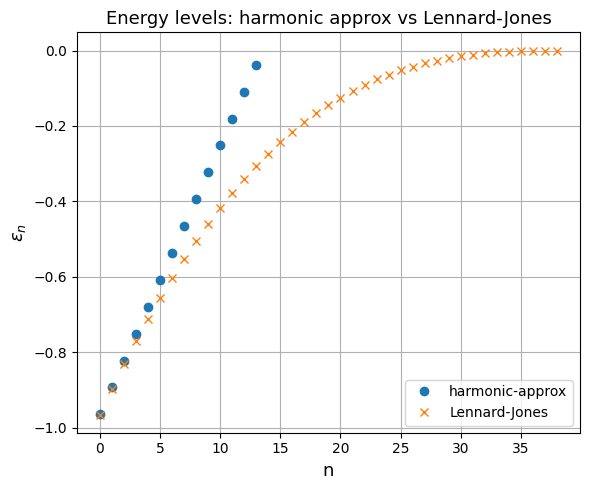

In [9]:
from matplotlib import pyplot as plt
plt.figure(figsize=(6, 5))
n1 = np.arange(14)
plt.plot(n1[:], en_hr[0:14], 'o', label='harmonic-approx')
n2 = np.arange(39)
plt.plot(n2[:], en_lj[0:39], 'x', label='Lennard-Jones')
plt.xlabel('n', fontsize=13)
plt.ylabel(r'$\epsilon_n$', fontsize=13)
plt.title('Energy levels: harmonic approx vs Lennard-Jones', fontsize=13)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

<div >

### Analysis  Task 6

For small $n$, the two results are close because the motion stays near the bottom of the well, where the Lennard-Jones potential looks almost like a parabola.

For larger $n$, the full Lennard-Jones levels are lower and closer together. This happens because the real well becomes softer on the outside and ends at $\epsilon=0$, while the harmonic approximation keeps going forever.

</div>

<div >

---
## Task 7  Effect of the Accuracy Parameter on the Computation of ε₁₈

For $n=18$, the code repeats the calculation with `ep` from $10^{-3}$ to $10^{-12}$. The root tolerances use `ep`, and the integral tolerance is `1e4*ep`.

</div>

In [10]:
mone_v = 0
mone_s = 0
ep = 1e-3

def v_lj_t7(x):
    global mone_v
    mone_v += 1  # count potential evaluations
    return 4.0 * (1.0/x**12 - 1.0/x**6)

gamma = 150

def s_t7(energy, ep_val):
    global mone_s
    mone_s += 1  # count action-integral evaluations
    # Exact Lennard-Jones turning points for this trial energy.
    sq = np.sqrt(max(0., 1.0 + energy))
    x_1 = (2.0 / (1.0 + sq))**(1/6)
    x_2 = (2.0 / (1.0 - sq))**(1/6)
    delta = 1e-9 * (x_2 - x_1)
    ff = lambda x: np.sqrt(max(0., energy - v_lj_t7(x)))
    # The assignment uses an integration tolerance tied to ep.
    return gamma * f_integral(ff, x_1 + delta, x_2 - delta, 1e4*ep_val, 'recursive', 'gauss')

n = 18
print('secant - recursive - gauss ')
print(' %3s %20s %12s %6s %4s %12s' % ('n', ' en_p ', ' ep ', 'it_v', 'it_s', ' err '))
for ip in range(10):
    # Repeat the same energy-level calculation with a smaller tolerance each time.
    f = lambda e, n=n, ep_val=ep: s_t7(e, ep_val) - (n + 0.5) * np.pi
    mone_v, mone_s = 0, 0
    en_p = x_root(f, -.999, -1e-7, ep, ep, 'secant')
    mv_used, ms_used = mone_v, mone_s
    print(' %3d %20.16f %12.4e %6d %4d %12.4e' % (n, en_p, ep, mv_used, ms_used, f(en_p)))
    ep = ep / 10


secant - recursive - gauss 
   n                en_p           ep    it_v it_s         err 
  18  -0.1669234798531231   1.0000e-03    567    9  -1.5821e-03
  18  -0.1669121196818158   1.0000e-04    630   10  -2.0463e-06
  18  -0.1669121196818158   1.0000e-05    630   10  -2.0463e-06
  18  -0.1669121068401263   1.0000e-06    810   10  -2.6010e-07
  18  -0.1666104834618788   1.0000e-07   1395   11   1.8190e-12
  18  -0.1665476683527895   1.0000e-08   3087   11   1.7053e-12
  18  -0.1665468557581282   1.0000e-09   5553   11   1.7053e-12
  18  -0.1665468411375457   1.0000e-10   8145   11   1.7124e-12
  18  -0.1665468376986308   1.0000e-11  11511   11   1.7124e-12
  18  -0.1665468372161479   1.0000e-12  17640   12   7.1054e-15


<div >

### Analysis  Task 7

As `ep` gets smaller, $\epsilon_{18}$ settles to a stable value, but the number of function calls grows. Very small tolerances cost more and give only small extra changes. In this table, `ep` around $10^{-8}$ to $10^{-10}$ is already stable at the shown precision.

</div>

<div >

---
## Task 8  Repeat of Task 5 Using scipy Functions

Here `scipy.integrate.quad` and `scipy.optimize.brentq` replace the custom integral and root functions. The physics problem is unchanged.

</div>

In [11]:
from scipy import optimize as sp_opt
from scipy import integrate as sp_int

mone_v_sc = 0
mone_s_sc = 0

def v_lj_sc(x):
    global mone_v_sc
    mone_v_sc += 1  # count potential evaluations
    return 4.0 * (1.0/x**12 - 1.0/x**6)

gamma = 150

def s_scipy(energy):
    global mone_s_sc
    mone_s_sc += 1  # count action-integral evaluations
    # Use the same turning points as in the custom calculation.
    sq = np.sqrt(max(0., 1.0 + energy))
    x_1 = (2.0 / (1.0 + sq))**(1/6)
    x_2 = (2.0 / (1.0 - sq))**(1/6)
    ff = lambda x: np.sqrt(max(0., energy - v_lj_sc(x)))
    # quad returns both the integral value and an error estimate.
    result, _ = sp_int.quad(ff, x_1, x_2, limit=200)
    return gamma * result

en_lj_sc = np.zeros(39)
m_v_sc   = np.zeros(39)
m_s_sc   = np.zeros(39)
f_n_sc   = np.zeros(39)

for n in range(39):
    # Brent's method solves the same BSW equation as x_root.
    f = lambda e, n=n: s_scipy(e) - (n + 0.5) * np.pi
    mone_v_sc, mone_s_sc = 0, 0
    en_lj_sc[n] = sp_opt.brentq(f, -.999, -1e-7, xtol=1e-6)
    m_v_sc[n], m_s_sc[n], f_n_sc[n] = mone_v_sc, mone_s_sc, f(en_lj_sc[n])

print(f"{'n':>3} {'en_lj_scipy':>20} {'en_lj_custom':>20} {'diff':>12} {'m_v':>6} {'m_s':>4}")
print("-" * 75)
for n in range(39):
    print('%3d %20.16f %20.16f %12.4e %6d %4d' % (
        n, en_lj_sc[n], en_lj[n], en_lj_sc[n]-en_lj[n], m_v_sc[n], m_s_sc[n]))


  n          en_lj_scipy         en_lj_custom         diff    m_v  m_s
---------------------------------------------------------------------------
  0  -0.9647641225256148  -0.9647641355243147   1.2999e-08   2730    6
  1  -0.8966715827641335  -0.8966715865672182   3.8031e-09   3129    7
  2  -0.8317034738144065  -0.8317034350088436  -3.8806e-08   3129    7
  3  -0.7698017365116202  -0.7698014978347520  -2.3868e-07   3129    7
  4  -0.7109066347073530  -0.7109066406773394   5.9700e-09   3129    7
  5  -0.6549587662977008  -0.6549587723902167   6.0925e-09   3528    8
  6  -0.6018968089795543  -0.6018968117069716   2.7274e-09   3528    8
  7  -0.5516586677068518  -0.5516586773780595   9.6712e-09   3528    8
  8  -0.5041812024582299  -0.5041812132796819   1.0821e-08   3528    8
  9  -0.4594001990594163  -0.4594002112829182   1.2224e-08   3528    8
 10  -0.4172503394159475  -0.4172503539880175   1.4572e-08   3528    8
 11  -0.3776651709292397  -0.3776651908742555   1.9945e-08   3528    8
 

<div >

### Analysis  Task 8

`quad` and `brentq` are trusted scipy routines, so they give a useful check on the custom code. The `diff` column is much smaller than the custom root tolerance, which means the two methods agree. Scipy usually needs fewer calls because its error checks are more advanced.

</div>